In [142]:
%load_ext autoreload

%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import sys  
sys.path.insert(1, '/home/wecapstor1/caph/mppi147h/eROdata')
import eROdata
from eROdata import *
from SherpaSpectralModel import *

In [2]:
import sys
import numpy as np
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, solar_system, get_body_barycentric, get_body, EarthLocation, AltAz
from astropy.time import Time
from regions import CircleSkyRegion, RectangleSkyRegion
from gammapy.maps import WcsGeom, MapAxis, Map, WcsNDMap
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, FoVBackgroundMaker
from gammapy.data import DataStore
from gammapy.datasets import Datasets, FluxPointsDataset, MapDataset, MapDatasetOnOff
from gammapy.modeling import Fit
from gammapy.modeling.models import SkyModel, LogParabolaSpectralModel, PointSpatialModel, PowerLawSpectralModel, FoVBackgroundModel, Models,ExpCutoffPowerLawSpectralModel, TemplateSpatialModel, NaimaSpectralModel, SpectralModel
from gammapy.estimators import FluxPoints,FluxPointsEstimator, ExcessMapEstimator, TSMapEstimator
from gammapy.visualization import plot_distribution
from gammapy.stats import ts_to_sigma
import naima
import gammapy

In [66]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Creating a 3D eROSITA dataset:

The basis for any eROSITA data products are the eROSITA event files. Find and download all eventfiles covering your region from https://erosita.mpe.mpg.de/dr1/erodat/catalogue/search/ (DR1) or https://erosita.mpe.mpg.de/edr/eROSITAObservations/ (EDR).

It is recommended to use the provided snakemake workflows to create the eROSITA data products (eROSITA_generate_files) or the full dataset (eROSITA_full_dataset).

Snakemake installation in a dedicated environment is easy (see https://snakemake.readthedocs.io/en/stable/getting_started/installation.html) and can make use of the eSASS software via a docker and the appropriate gammapy environment easily. No further installations are then necessary for dataset creation.

All necessary information is supplied in the file `config.py`. See file for detailed description of parameter meanings.

To run the snakemake workflows then use:
```
snakemake -s eROdata_full_dataset --sdm conda
```
To run them on a cluster (recommended), with e.g. SLURM, the arguments ` --executor slurm --default-resources --jobs 100` can be used (see `snakemake` documentation for options). Settings for cluster runtime and memory are included in `config.py`.

Most settings are available in the snakemake workflow, for maximum control the data products can be created and assembled manually.

# Loading a 3D eROSITA dataset into Gammapy:

A 3D eROSITA MapDataset or MapDatasetOnOff can be loaded into Gammapy like any other dataset. The dataset is created in logarithmic interpolation, the function `to_lin()` changes this to linear interpolation.

In [65]:
erosita = to_lin(MapDatasetOnOff.read("/home/wecapstor1/caph/mppi147h/pwn_analysis/DR1_eROSITA_data/MSH15-52/data_products_snakemake/dataset_stacked.fits.gz",format="gadf",name="erosita")).cutout(erosita.counts.geom.center_skydir,0.5*u.deg)

Let's take a first look at our dataset!

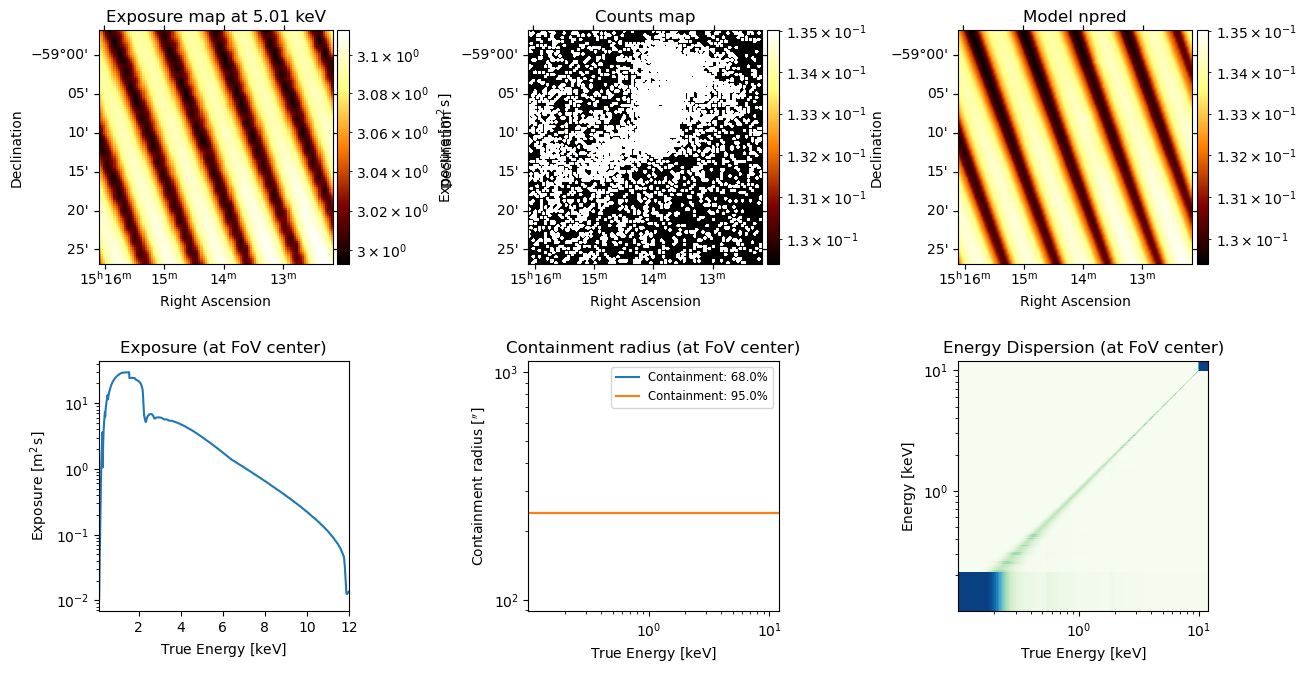

In [67]:
erosita.peek()

The pixel size is a lot smaller than that of gamma-ray instruments, the average spatial resolution is ~26 arcsec. Our data encompasses events from 0.1 to 12.0 keV, the energy range of 0.2 to 9-10.0 keV is generally considered usable. If the eROSITA background model is used, 0.25 keV should be used as the lower limit.

Additionally there are many point sources in the FoV. We define a mask to limit both our energy range and exclude point sources. For point source exclusion the DR1 catalog is used (available under https://erosita.mpe.mpg.de/dr1/AllSkySurveyData_dr1/Catalogues_dr1/, note that different catalogs might apply for EDR data!), the path to which you will need to supply to the function.
Additionally we want to mask out the thermal remnant RCW 89 and the central pulsar by supplying their regions.

In [90]:
mask_erosita=make_exclusion_mask(erosita, catalog_path="/home/wecapstor1/caph/mppi147h/eRASS1_Main/",
                                 include=Regions.parse("fk5;circle(228.4788924,-59.1357402,0.1666666666)", format="ds9"),
                                 exclude=Regions.parse("fk5;circle(228.3789225,-59.0181796,0.0832210) fk5;circle(228.4788924, -59.1357402, 0.0166666666)", format="ds9"))

In [91]:
erosita.mask_safe=mask_erosita
make_energy_mask(erosita, energy_bounds=[0.2,9.0]*u.keV)

In [92]:
erosita.mask_safe.plot_interactive()

interactive(children=(SelectionSlider(continuous_update=False, description='Select energy:', layout=Layout(wid…

Now we are ready for a first analysis!

# Fitting a 3D eROSITA dataset:

A look at a significance map already shows us that there is significant emission present here:

In [192]:
estimator = ExcessMapEstimator(
    correlation_radius="0.01 deg",
    energy_edges = [0.2, 9]*u.keV,

    selection_optional=[],)

excessmap_wo_fit = estimator.run(erosita)

/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.0.1/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.0.1/lib/python3.12/site-packages/gammapy/stats/counts_statistic.py:399: RuntimeWarning: invalid value encountered in multiply
  return self.alpha * self.n_off
/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.0.1/lib/python3.12/site-packages/gammapy/stats/fit_statistics.py:228: RuntimeWarning: invalid value encountered in multiply
  C = alpha * (n_on + n_off) - (1 + alpha) * mu_sig
/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.0.1/lib/python3.12/site-packages/gammapy/stats/fit_statistics.py:229: RuntimeWarning: invalid value encountered in multiply
  D = np.sqrt(C**2 + 4 * alpha * (alpha + 1) * n_off * mu_sig)
/home/wecapstor1/caph/mppi

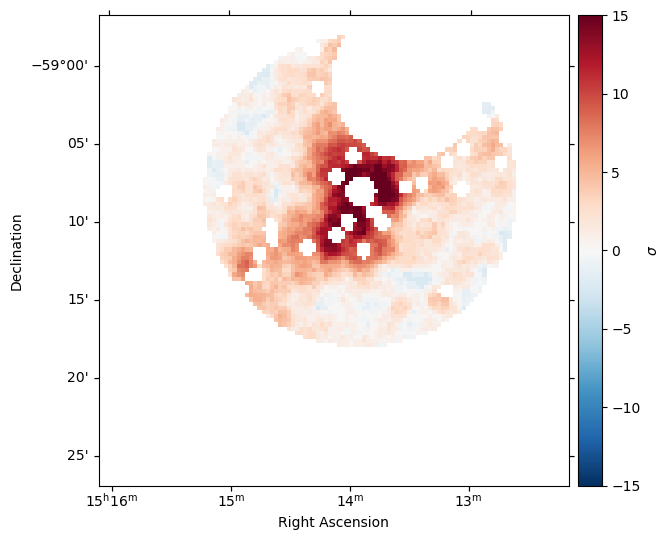

In [193]:
fig = plt.figure(figsize=(6,6),layout="constrained")
ax = excessmap_wo_fit["sqrt_ts"].plot(clim=[-15,15], cmap=plt.cm.RdBu_r,add_cbar=True,kwargs_colorbar={"label" : r"$\sigma$"})

X-ray data up to ~1-2 keV is affected by ISM absorption. To describe this in our model we use the TBabs model (Wilms et al., 2000). To import it into Gammapy we use the SherpaWrapper that is provided in gammapy-mwl (https://github.com/gammapy/gammapy-mwl).

In [114]:
#sys add path to SherpaWrapper
#from SherpaWrapper import *
from sherpa.astro.xspec import XSTBabs, XSpowerlaw
from sherpa.astro import xspec

In [115]:
xspec.set_xsabund('wilm')

absorption_sherpa = XSTBabs()
absorption_sherpa.nH = 1.36

absorption_gammapy = SherpaSpectralModel(absorption_sherpa, default_units=(u.keV, 1))

 Solar Abundance Vector set to wilm:  Wilms, J., Allen, A. & McCray, R. ApJ 542 914 (2000) (abundances are set to zero for those elements not included in the paper).


In [116]:
xspec.set_xsabund('wilm')
pl_sherpa1 = XSpowerlaw()#name='powerlaw')#,[2,1e3])#PowLaw1D()
pl_sherpa1.PhoIndex = 1.9
pl_sherpa1.norm = 0.005

absorption_sherpa1 = XSTBabs()
absorption_sherpa1.nH = 1.36

spectral_model=SherpaSpectralModel(absorption_sherpa1*pl_sherpa1)

 Solar Abundance Vector set to wilm:  Wilms, J., Allen, A. & McCray, R. ApJ 542 914 (2000) (abundances are set to zero for those elements not included in the paper).


We define a `SkyModel` using an absorbed powerlaw `SpectralModel` and a 2D Gaussian `SpatialModel` as an approximation for the morphology of MSH 15-52.

In [118]:
spatial_model=GaussianSpatialModel(lon_0=228.4788924*u.deg, lat_0=-59.1357402*u.deg, frame="fk5",sigma=6*u.arcmin,e=0.9,phi=140*u.deg)

spectral_model = spectral_model #absorption_gammapy*PowerLawSpectralModel(
#    index=2.7, amplitude="5.8e-3 cm-2 s-1 keV-1", reference="1 keV"
#)

source = SkyModel(
    spectral_model=spectral_model,
    spatial_model=spatial_model,
    name="source-gc",
)

source.parameters["lon_0"].min=228.4788924-0.15
source.parameters["lon_0"].max=228.4788924+0.15
source.parameters["lat_0"].min=-59.1357402-0.15
source.parameters["lat_0"].max=-59.1357402+0.15
source.parameters["nH"].frozen=False
source.parameters["nH"].max=1.36

source.parameters["e"].frozen=False
source.parameters["phi"].frozen=False

source.parameters["e"].min=0
source.parameters["e"].max=1.0
source.parameters["e"].value=0.8

source.parameters["sigma"].min=2.0

source.parameters["norm"].min=1e-8
source.parameters["norm"].max=1e3

erosita.models=[source]

In [128]:
fit = Fit()
result = fit.run(datasets=[erosita])

print(result)

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 288
	total stat : 24223.05

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



In [129]:
source

SkyModel(spatial_model=<gammapy.modeling.models.spatial.GaussianSpatialModel object at 0x7f1e63b05e20>, spectral_model=<SherpaSpectralModel.SherpaSpectralModel object at 0x7f1e1da7dd60>)temporal_model=None)

The fit was a success! We use the `minuit` backend. With more complex X-ray models this can run into problems in which case the `sherpa` backend can help.

A look at the post-fit significance map shows that the excess has been greatly reduced.

In [131]:
estimator_fit = ExcessMapEstimator(
    correlation_radius="0.01 deg",
    energy_edges = [0.2, 9]*u.keV,

    selection_optional=[],correlate_off=False)

excessmap_fit = estimator_fit.run(erosita)

/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.0.1/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


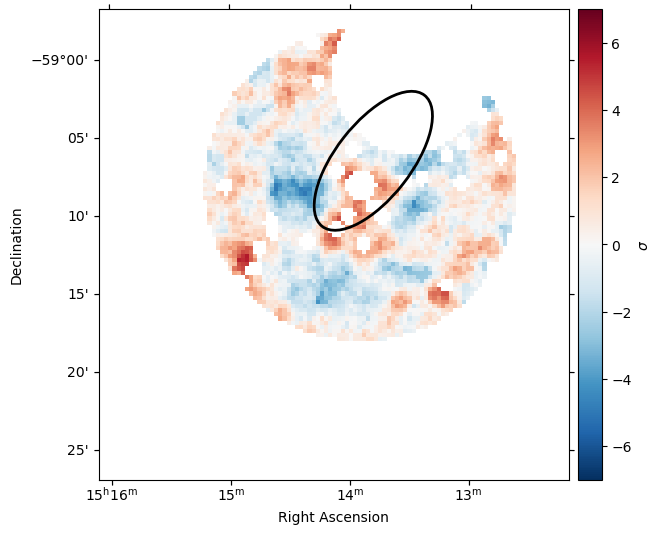

In [132]:
fig = plt.figure(figsize=(6,6),layout="constrained")
ax = excessmap_fit["sqrt_ts"].plot(clim=[-7,7], cmap=plt.cm.RdBu_r,add_cbar=True,kwargs_colorbar={"label" : r"$\sigma$"})
reg=source.spatial_model.to_region().to_pixel(erosita.counts.geom.to_image().wcs)
reg.plot(facecolor='darkblue', linewidth=2, edgecolor='black',ax=ax)

Note that due to the data format you should use the `to_spectrum_dataset_xray()` function to extract 1D spectra from 3D eROSITA datasets, such as in the following example.

In [195]:
region=CircleSkyRegion(center=SkyCoord(228.4788924, -59.1357402,unit="deg",frame="icrs"),radius=0.17*u.deg)
spectrum=to_spectrum_dataset_xray(self=erosita,on_region=region)

/home/wecapstor1/caph/mppi147h/eROdata/eROdata.py:561: RuntimeWarning: invalid value encountered in divide
  counts_off.data = np.nan_to_num(np.divide(counts_off.data,area_factor.data))
/home/wecapstor1/caph/mppi147h/eROdata/eROdata.py:567: RuntimeWarning: invalid value encountered in divide
  acceptance.data = np.nan_to_num(np.divide(acceptance.data,area_factor.data))


[[[False]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ True]]

 [[ 

/home/wecapstor1/caph/mppi147h/eROdata/eROdata.py:574: RuntimeWarning: invalid value encountered in divide
  acceptance_off.data = np.nan_to_num(np.divide(acceptance_off.data,(area_factor.data*area_factor.data)))


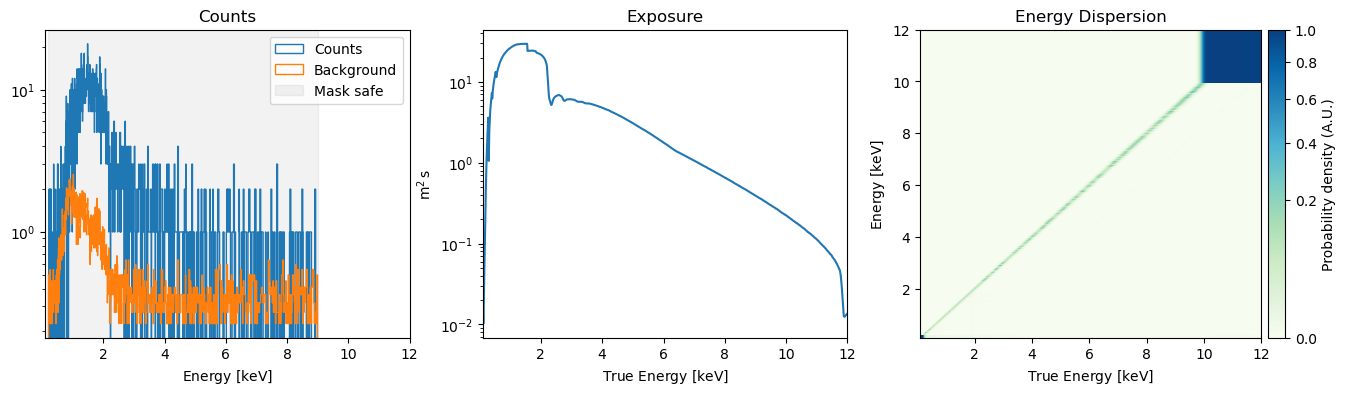

In [196]:
spectrum.peek()

# Fitting the eROSITA background

So far we have worked with a `MapDatasetOnOff`, i.e. a dataset with OFF counts. If you would like to model the background instead, working with `MapDataset`s instead is also possible. The background spectra are provided with all created datasets and can be fit directly.

`MapDataset`s can directly be created in the `snakemake` pipeline. For illustration purposes, we quickly convert our previous dataset here:

In [134]:
erosita2=erosita.to_map_dataset()
erosita2.background.data = np.zeros_like(erosita2.background.data)

We set the background map to zero, since we are not using a HESS-style background model.

Now we fit the background model on the background spectrum.
The eROSITA background model (Ponti et al. 2023, Yeung et al. 2023) consists of 2 components that need to be treated separately (astrophysical and instrumental/particle background), called `bkg` and `fwc` here. The function `fit_erosita_background()` helps automatize the fitting procedure. Since the background model `bkg` is fairly complex, the `sherpa` backend is used.

In [48]:
backgr = to_lin(SpectrumDataset.read("/home/wecapstor1/caph/mppi147h/pwn_analysis/DR1_eROSITA_data/MSH15-52/data_products_snakemake/dataset_stacked_backgr.fits.gz",format="gadf"))

In [50]:
fit_erosita_background(backgr)

/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.0.1/lib/python3.12/site-packages/sherpa/astro/xspec/__init__.py:1576: FutureWarning: calc() requires pars,lo,hi arguments, sent 2 arguments
  warnings.warn(emsg, FutureWarning)


 Solar Abundance Vector set to wilm:  Wilms, J., Allen, A. & McCray, R. ApJ 542 914 (2000) (abundances are set to zero for those elements not included in the paper).
Reading APEC data from 3.0.9



/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.0.1/lib/python3.12/site-packages/sherpa/astro/xspec/__init__.py:1576: FutureWarning: calc() requires pars,lo,hi arguments, sent 2 arguments
  warnings.warn(emsg, FutureWarning)
/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.0.1/lib/python3.12/site-packages/sherpa/astro/xspec/__init__.py:1576: FutureWarning: calc() requires pars,lo,hi arguments, sent 2 arguments
  warnings.warn(emsg, FutureWarning)
/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.0.1/lib/python3.12/site-packages/sherpa/astro/xspec/__init__.py:1576: FutureWarning: calc() requires pars,lo,hi arguments, sent 2 arguments
  warnings.warn(emsg, FutureWarning)
/home/wecapstor1/caph/mppi147h/software/miniforge3/envs/gammapy-2.0.1/lib/python3.12/site-packages/sherpa/astro/xspec/__init__.py:1576: FutureWarning: calc() requires pars,lo,hi arguments, sent 2 arguments
  warnings.warn(emsg, FutureWarning)
No covariance estimate - not

OptimizeResult

	backend    : sherpa
	method     : sherpa
	success    : True
	message    : Optimization terminated successfully
	nfev       : 1627
	total stat : -32174.90




(<Axes: xlabel='Energy [$\\mathrm{keV}$]', ylabel='$\\mathrm{}$'>,
 <Axes: xlabel='Energy [$\\mathrm{keV}$]', ylabel='Residuals\ndata - model'>)

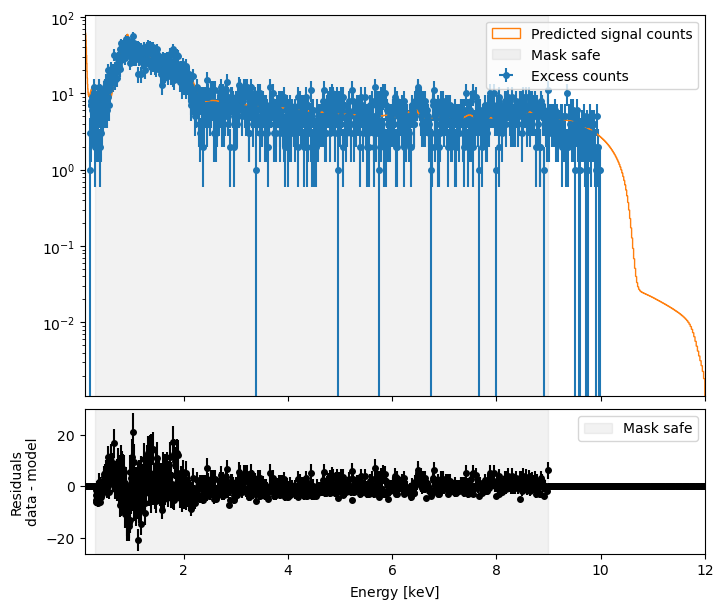

In [51]:
backgr.plot_fit()

We then export our `bkg` model as a `TemplateSpectralModel` and apply both models to our dataset. We then refit our models.

Both background models are defined with a `ConstantSpatialModel`. Note that this can help separate your background component from the source but presents an approximation for the `fwc` component.

In [180]:
bkg = erosita_background_to_template(backgr.models["manual_bkg"])

In [182]:
erosita2.models = [source.copy(), bkg, backgr.models["fwc"].copy()]

In [183]:
fit2 = Fit()
result2 = fit.run(datasets=[erosita2])

print(result2)

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 1006
	total stat : 28187.42

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



In [184]:
erosita2

Since the `fwc` model is not folded with the exposure, it does not have flux units and cannot be plotted along with the other models. Use the `npred` predicted number of counts for visualization instead.

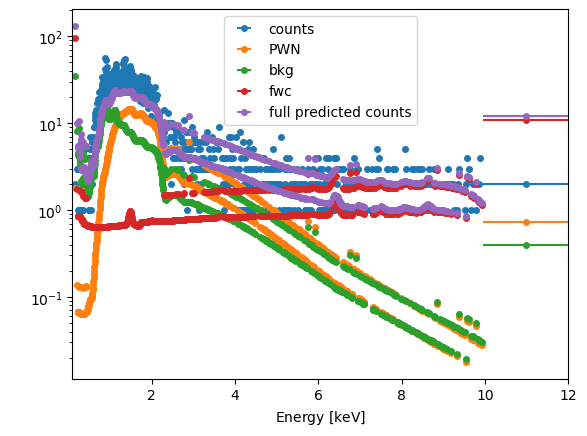

In [190]:
erosita2.counts.get_spectrum().plot(label="counts")
erosita2.npred_signal(model_names=["G-lJ7rlZ"]).get_spectrum().plot(label="PWN")
erosita2.npred_signal(model_names=["bkg"]).get_spectrum().plot(label="bkg")
erosita2.npred_signal(model_names=["2RsIh-bi"]).get_spectrum().plot(label="fwc")
erosita2.npred().get_spectrum().plot(label="full predicted counts")
plt.legend()

Exporting and importing a background model from `PyXspec` is also possible with the following functions:

In [ ]:
export_pyxspec_model(filename,name="PyXspec model name") # use this command in PyXspec
model = import_erosita_background_model(filename, fwc=False) # use this command in Gammapy